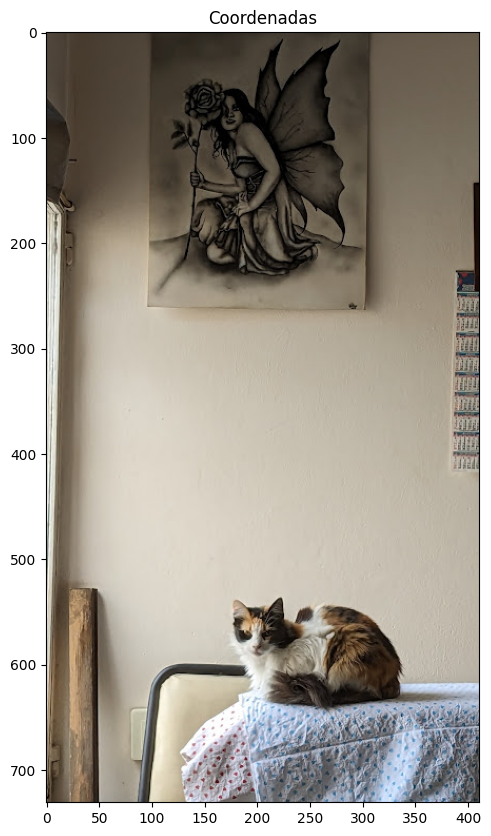

Forma: (731, 411, 3)


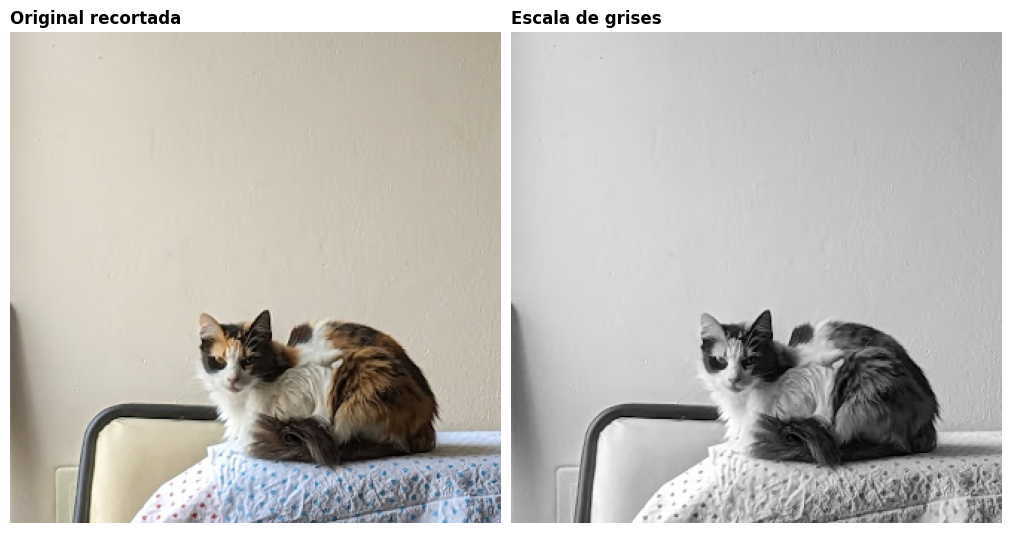

Guardada en: C:\Users\cin_c\OneDrive\Desktop\Repositorios\pdi\coronel-cintia-pdi-1c-2026\006_fotografia_digital\imagenes\procesadas\simplicidad_grises.jpg


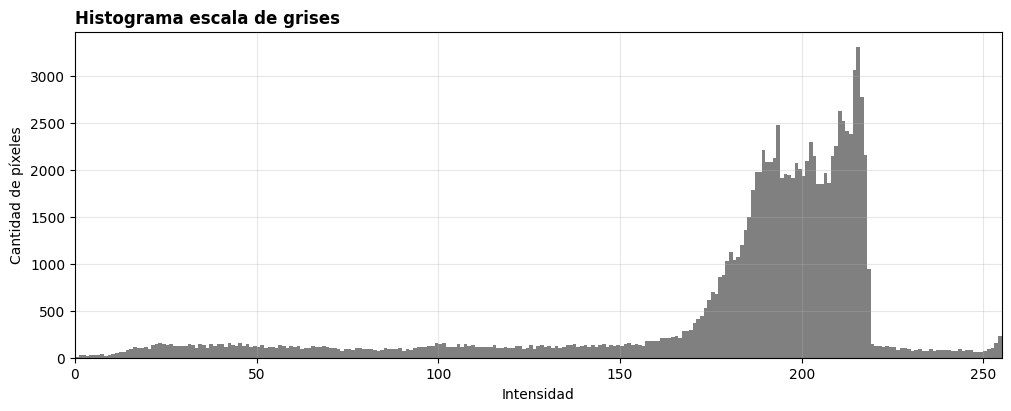

In [ ]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# Ubicación de la imagen
carpeta_imagenes = Path("../imagenes/originales")
carpeta_salidas = Path("../imagenes/procesadas")
carpeta_salidas.mkdir(parents=True, exist_ok=True)

# Carga
img_simplicidad_bgr = cv2.imread(str(carpeta_imagenes / "simplicidad.jpg"))
if img_simplicidad_bgr is None:
    raise FileNotFoundError(f"No se encontró la imagen en: {(carpeta_imagenes / 'simplicidad.jpg').resolve()}")
img_simplicidad_rgb = cv2.cvtColor(img_simplicidad_bgr, cv2.COLOR_BGR2RGB)

# Coordenadas para definir recorte
plt.figure(figsize=(6, 10))
plt.imshow(img_simplicidad_rgb)
plt.title("Coordenadas")
plt.axis("on")
plt.show()
print("Forma:", img_simplicidad_rgb.shape)

# Recorte
img_recortada_simplicidad = img_simplicidad_rgb[350:680, 50:380]

# Conversión a escala de grises sobre el recorte
img_recortada_gris = cv2.cvtColor(img_recortada_simplicidad, cv2.COLOR_RGB2GRAY)

# Comparación color vs grises
figura, ejes = plt.subplots(1, 2, figsize=(10, 6), constrained_layout=True)
ejes[0].imshow(img_recortada_simplicidad)
ejes[0].set_title("Original recortada", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(img_recortada_gris, cmap="gray")
ejes[1].set_title("Escala de grises", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()

# Guardo
cv2.imwrite(str(carpeta_salidas / "simplicidad_grises.jpg"), cv2.cvtColor(img_recortada_gris, cv2.COLOR_GRAY2BGR))
print(f"Guardada en: {(carpeta_salidas / 'simplicidad_grises.jpg').resolve()}")

# Histograma de la imagen en escala de grises
plt.figure(figsize=(10, 4), constrained_layout=True)
plt.hist(img_recortada_gris.flatten(), bins=256, range=[0, 256], color="gray")
plt.title("Histograma escala de grises", fontweight="bold", loc="left")
plt.xlabel("Intensidad")
plt.ylabel("Cantidad de píxeles")
plt.xlim(0, 255)
plt.grid(alpha=0.3)
plt.show()